To install, ´conda env create -f environment-VitisUnified.yml´, or to update env ´conda env update -f environment-VitisUnified.yml´. Remember to restart kernel.

In [5]:
# Check available backends for vitisunified
import hls4ml
hls4ml.backends.backend.get_available_backends()

['vivado',
 'vivadoaccelerator',
 'vitis',
 'vitisunified',
 'quartus',
 'catapult',
 'symbolicexpression',
 'oneapi',
 'libero']

# Example of creating a model and importing into a Vivado-project
Based on [hls4ml-tutorial part 3](https://github.com/fastmachinelearning/hls4ml-tutorial/blob/main/part3_compression.ipynb) and [Tanawin1701d/vitisUnifiedTutorial](https://github.com/Tanawin1701d/vitisUnifiedTutorial).

To store multiple revisions, the following parameters are used throughout. Make sure to update them if you want to keep multiple revisions.

Make sure to start this from conda environment with Vitis loaded to path.
´conda activate hls4ml-kv260-testenv´

In [6]:
import os
model_to_test = 'testmodel'
model_revision = 2
hls4ml_revision = 'VitisUnifiedKV260_2023.2_verification'

base_dir = os.path.abspath(model_to_test)
model_dir = os.path.join(base_dir, str(model_revision))
os.makedirs(model_dir, exist_ok=True)

description = """
# Model Configuration

Testing 2023.2 still works as expected

- **Model architecture description**: {model_to_test}
- **Model Revision**: {model_revision}
- **HLS4ML Revision**: {hls4ml_revision}
- **Backend**: Vitis Unified [[https://github.com/fastmachinelearning/hls4ml/pull/1376]]
- **Target Device**: KV260 (xck26-sfvc784-2LV-c)
- **Dataset**: HLS4ML LHC Jets
"""
output_dir = os.path.join(model_dir, f"hls4ml_prj_{hls4ml_revision}")
os.makedirs(output_dir, exist_ok=True)
with open(os.path.join(output_dir, "description.md"), "w", encoding="utf-8") as f:
    f.write(description)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import keras
import tensorflow as tf
import os

%matplotlib inline
seed = 0
np.random.seed(seed)

tf.random.set_seed(seed)



In [8]:
# Load into path and double check Vivado/Vits versions
os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH'] 
!vitis --version
!vitis_hls -version
!vivado -version


****** Vitis Development Environment
****** Vitis v2025.2 (64-bit)
  **** SW Build 6295257 on 2025-11-13-01:29:14
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2025 Advanced Micro Devices, Inc. All Rights Reserved.

/bin/bash: line 1: vitis_hls: command not found
vivado v2025.2 (64-bit)
Tool Version Limit: 2025.11
SW Build 6299465 on Fri Nov 14 12:34:56 MST 2025
IP Build 6300035 on Fri Nov 14 10:48:45 MST 2025
SharedData Build 6298862 on Thu Nov 13 04:50:51 MST 2025
Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
Copyright 2022-2025 Advanced Micro Devices, Inc. All Rights Reserved.


Load dataset and save data. If the data is already saved to disk, load the local cache.

In [9]:
# Use absolute paths for data files
x_train_val_path = os.path.join(base_dir, "x_train_val.npy")
x_test_path = os.path.join(base_dir, "x_test.npy")
y_train_val_path = os.path.join(base_dir, "y_train_val.npy")
y_test_path = os.path.join(base_dir, "y_test.npy")
classes_path = os.path.join(base_dir, "classes.npy")

if not os.path.exists(x_train_val_path):
    from tensorflow.keras.utils import to_categorical
    from sklearn.datasets import fetch_openml
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import LabelEncoder, StandardScaler
    
    data = fetch_openml('hls4ml_lhc_jets_hlf')
    x, y = data['data'], data['target']

    le = LabelEncoder()
    y = le.fit_transform(y)
    y = to_categorical(y, 5)
    # Change to float32
    x = x.astype(np.float32)
    y = y.astype(np.float32)
    # split
    x_train_val, x_test, y_train_val, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    x_train_val = scaler.fit_transform(x_train_val)
    x_test = scaler.transform(x_test)

    np.save(x_train_val_path, x_train_val)
    np.save(x_test_path, x_test)
    np.save(y_train_val_path, y_train_val)
    np.save(y_test_path, y_test)
    np.save(classes_path, le.classes_)
    classes = le.classes_
    print("Saved files")
else:
    x_train_val = np.load(x_train_val_path)
    x_test = np.load(x_test_path)
    y_train_val = np.load(y_train_val_path)
    y_test = np.load(y_test_path)
    classes = np.load(classes_path, allow_pickle=True)



In [10]:
# Prepare subset of testdata for simulation (running everything takes an unnecessary long time)
simulation_rows = 100
x_test_sim_path = os.path.join(base_dir, "x_test_sim.npy")
y_test_sim_path = os.path.join(base_dir, "y_test_sim.npy")
np.save(x_test_sim_path, x_test[:simulation_rows])
np.save(y_test_sim_path, y_test[:simulation_rows])

Load existing model, or create and train a new

In [11]:
load_existing_model = True

keras_model_path = os.path.join(model_dir, f"{model_to_test}_{model_revision}_model.keras")

if load_existing_model:
    from keras.models import load_model
    model = load_model(keras_model_path)
else:
    inputs = keras.Input(shape=(16,), name='linput')
    x = keras.layers.Dense(64, input_shape=(16,), name='fc1', kernel_initializer='lecun_uniform')(inputs)
    #x = keras.layers.Activation(activation='relu', name='relu1')(x)
    #x = keras.layers.Dense(32, name='fc2', kernel_initializer='lecun_uniform')(x)
    #x = keras.layers.Activation(activation='relu', name='relu2')(x)
    #x = keras.layers.Dense(32, name='fc3', kernel_initializer='lecun_uniform')(x)
    x = keras.layers.Activation(activation='relu', name='relu3')(x)
    x = keras.layers.Dense(5, name='output', kernel_initializer='lecun_uniform')(x)
    outputs = keras.layers.Activation(activation='softmax', name='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(optimizer="adam", loss=['categorical_crossentropy'], metrics=['accuracy'])
    model.fit(
        x_train_val,
        y_train_val,
        batch_size=1024,
        epochs=3,
        validation_split=0.25,
        shuffle=True,
    )
    model.save(keras_model_path)


In [12]:
print(classes)


['g' 'q' 't' 'w' 'z']


In [13]:
# Save results for plotting example curve in plots/
y_keras = model.predict(x_test)
from sklearn.metrics import accuracy_score
print("Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_keras, axis=1))))

y_keras_path = os.path.join(base_dir, "y_keras.npy")
np.save(y_keras_path, y_keras)

#plot ROC
#from plots import plotting
#plt.figure(figsize=(9, 9))
#_ = plotting.makeRoc(y_test, y_keras, classes)


#plt.figure(figsize=(9, 9))
#_ = plotting.makeRoc(y_test, y_keras, classes, style_semilogx=False)

 144/5188 ━━━━━━━━━━━━━━━━━━━━ 1s 350us/step 

5188/5188 ━━━━━━━━━━━━━━━━━━━━ 2s 341us/step
Accuracy: 0.7321746987951807


In [14]:
# Save the model summary to a text file
with open(os.path.join(model_dir, "summary.txt"), "w", encoding="utf-8") as f:
    model.summary(print_fn=lambda line: f.write(line + "\n"))

In [15]:
#from plots import plotting
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

y_keras = model.predict(x_test)
print("Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_keras, axis=1))))


   1/5188 ━━━━━━━━━━━━━━━━━━━━ 55s 11ms/step

5188/5188 ━━━━━━━━━━━━━━━━━━━━ 2s 331us/step
Accuracy: 0.7321746987951807


# Convert and synthesize with HLS4ML
Uses KV260 (xck26-sfvc784-2LV-c). 

In [16]:
import hls4ml
hls_model = hls4ml.converters.convert_from_keras_model(
    model, 
    backend     = 'vitisunified', 
    #project_name=f'{model_to_test}_{model_revision}_hls4ml_prj_{hls4ml_revision}', # Bug ved feil bruk av denne når axi_master.cpp skal hentes i `vitis_unified_writer`
    output_dir  = output_dir, 
    board       = 'kv260',
    #part        = 'xck26-sfvc784-2LV-c', # default fra supported-boards.json fungerer ikke i Vivado 2025.2
    clock_period= '5ns',
    # Set input data for model simulation
    input_data_tb= x_test_sim_path,
    output_data_tb=y_test_sim_path,
    #in_stream_buf_size = 256,
    #out_stream_buf_size = 128,
    #input_type  = "double",
    #output_type = "double",
    #xpfmPath    = XPFM_PATH,
    #io_type     = "io_stream",
    #strategy    = "latency",
    #granularity = "name",
    #amt_query   = 10,
    #axi_mode    = "axi_stream", #"axi_master",
)
hls_model.compile()
#hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True,to_file=os.path.join(output_dir, "model-plot.png"))

In [17]:
print(hls_model.config.config)
hls_model.config.get_output_dir()
hls_model.config.backend.writer.get_vitis_linker_dir(hls_model)

{'OutputDir': '/home/ncgadmin/Bachelor/HLS4ML_testbench_KV260/development/_OldExports/testmodel/2/hls4ml_prj_VitisUnifiedKV260_2023.2_verification', 'ProjectName': 'myproject', 'Backend': 'VitisUnified', 'Version': '1.0.0', 'Part': 'xck26-sfvc784-2LV-c', 'ClockPeriod': '5ns', 'ClockUncertainty': '12.5%', 'IOType': 'io_stream', 'HLSConfig': {'Model': {'Precision': 'fixed<16,6>', 'ReuseFactor': 1, 'BitExact': None}}, 'WriterConfig': {'Namespace': None, 'WriteWeightsTxt': True, 'WriteTar': False, 'TBOutputStream': 'both', 'WriteEmulationConstants': False}, 'VitisUnifiedConfig': {'Board': 'kv260', 'axi_mode': 'axi_master', 'in_stream_buf_size': 128, 'out_stream_buf_size': 128, 'Driver': 'python', 'InputDtype': 'float', 'OutputDtype': 'float'}, 'KerasModel': <Functional name=functional, built=True>, 'InputData': '/home/ncgadmin/Bachelor/HLS4ML_testbench_KV260/development/_OldExports/testmodel/x_test_sim.npy', 'OutputPredictions': '/home/ncgadmin/Bachelor/HLS4ML_testbench_KV260/development/_

'/home/ncgadmin/Bachelor/HLS4ML_testbench_KV260/development/_OldExports/testmodel/2/hls4ml_prj_VitisUnifiedKV260_2023.2_verification/vitis_workspace/system_link'

Test the HLS-model if it actually works

In [14]:
hls_model.predict(np.ascontiguousarray(x_test[:10]))

array([[5.00000000e-01, 4.27734375e-01, 4.10156250e-02, 4.88281250e-02,
        1.04492188e-01],
       [7.42187500e-02, 6.66992188e-01, 5.85937500e-03, 2.30468750e-01,
        1.30859375e-01],
       [1.89453125e-01, 7.12890625e-02, 7.99804688e-01, 0.00000000e+00,
        0.00000000e+00],
       [1.26953125e-02, 6.83593750e-03, 1.00000000e+00, 7.91015625e-02,
        0.00000000e+00],
       [3.71093750e-02, 3.12500000e-02, 1.00000000e+00, 9.76562500e-04,
        0.00000000e+00],
       [5.17578125e-02, 1.37695312e-01, 4.00390625e-01, 1.33789062e-01,
        3.11523438e-01],
       [4.44335938e-01, 2.86132812e-01, 1.12304688e-01, 9.57031250e-02,
        6.15234375e-02],
       [6.66992188e-01, 1.19140625e-01, 4.39453125e-02, 1.01562500e-01,
        8.39843750e-02],
       [6.54296875e-02, 5.71289062e-01, 2.05078125e-02, 2.45117188e-01,
        1.90429688e-01],
       [1.95312500e-03, 8.78906250e-03, 1.75781250e-02, 1.00000000e+00,
        1.90429688e-01]], dtype=float32)

In [15]:
from hls4ml.model.profiling import numerical
#plots = numerical(model=model, hls_model=hls_model, X=x_test)

# Simulation
[vitis unified tutorial](https://github.com/Tanawin1701d/vitis_unified_backend_tutorial/blob/master/03_co_simulation.ipynb)

In [19]:
# Build and do co-simulation
hls_model.build(
    synth=True, # Only needs to run first time
    csim=True,
    cosim=True,

    ) 


****** v++ v2025.2 (64-bit)
  **** SW Build 6295257 on 2025-11-13-01:29:13
  **** Start of session at: Mon May 18 16:09:46 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2025 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2025.2 6295257
INFO: [HLS 200-2005] Using work_dir /home/ncgadmin/Bachelor/HLS4ML_testbench_KV260/development/_OldExports/testmodel/2/hls4ml_prj_VitisUnifiedKV260_2023.2_verification/vitis_workspace/myproject/vitis_unified_project 
INFO: [HLS 200-2176] Writing Vitis IDE component file /home/ncgadmin/Bachelor/HLS4ML_testbench_KV260/development/_OldExports/testmodel/2/hls4ml_prj_VitisUnifiedKV260_2023.2_verification/vitis_workspace/myproject/vitis_unified_project/vitis-comp.json
INFO: [HLS 200-10] Creating and opening component '/home/ncgadmin/Bachelor/HLS4ML_testbench_KV260/development/_OldExports/testmodel/2/hls4ml_prj_VitisUnifiedKV260_2023.2_verification/vitis_workspace/myproject/vitis_unified_project'.

In [ ]:
y_baseline = hls_model.predict(np.ascontiguousarray(x_test[:simulation_rows]))
#y_baseline = model.predict(np.ascontiguousarray(x_test[:simulation_rows]))
y_simulation = np.loadtxt(os.path.join(output_dir, "tb_data/rtl_cosim_results.log"))

In [ ]:
print(f"y_baseline shape: {y_baseline.shape} and y_simulation: {y_simulation.shape}")
#print(y_simulation)

In [ ]:
assert np.allclose(y_baseline, y_simulation, rtol=0.0, atol=1e-4), (
    "The results from bridge and cosim are NOT equal!"
)
print("\n✅ RTL co-simulation comparison passed, absolute difference is less than 1e-4 (atol=1e-4).")

In [ ]:
from sklearn.metrics import accuracy_score
print("Difference in inference-calculations between HLS4ML bridge and simulated inference (first rows):")
abs_diff = y_baseline[:3] - y_simulation[:3]
print(np.round(abs_diff, 8))

mse = np.mean(np.square(y_baseline - y_simulation))
print(f"MSE: {mse}")


print("Baseline  Accuracy: {}".format(accuracy_score(np.argmax(y_test[:simulation_rows], axis=1), np.argmax(y_baseline, axis=1))))
print("Simulation Accuracy: {}".format(accuracy_score(np.argmax(y_test[:simulation_rows], axis=1), np.argmax(y_simulation, axis=1))))

# Generate bitfile

Implementation details
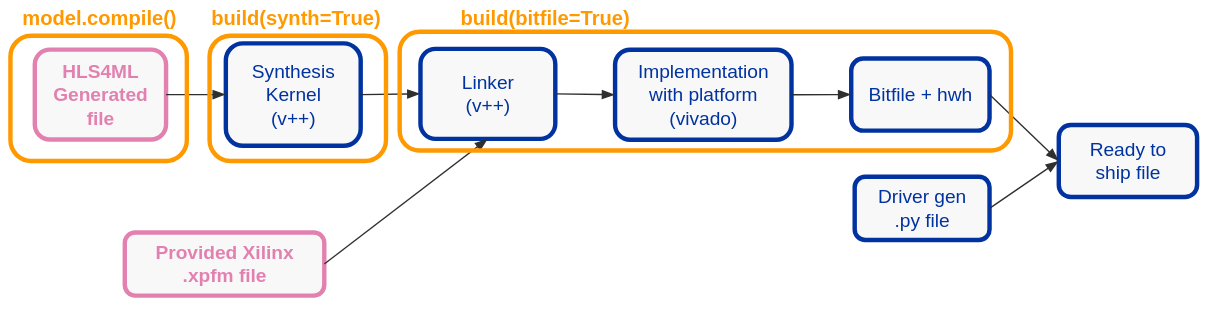
[Origin and more information](https://github.com/fastmachinelearning/hls4ml/pull/1376)

In [17]:
# Hotfix for crashing, see README
os.environ['LD_PRELOAD'] = '/lib/x86_64-linux-gnu/libudev.so.1'

# Create complete bitfile (Vitis Unified-backend) or IP-block (Vitis-backend) 
hls_model.build(
    synth=True, # Does not need to be synthesised twice
    #csim=True,
    bitfile=True
    ) 


****** v++ v2023.2 (64-bit)
  **** SW Build 4026344 on 2023-10-11-15:42:10
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

Running Dispatch Server on port: 45285
INFO: [v++ 60-1548] Creating build summary session with primary output /home/ncgadmin/Bachelor/HLS4ML_testbench_KV260/development/_OldExports/testmodel/2/hls4ml_prj_VitisUnifiedKV260_2023.2_verification/vitis_workspace/myproject/vitis_unified_project/vitis_unified_project.hlscompile_summary, at Thu May 14 23:50:09 2026
INFO: [v++ 82-31] Launching vitis_hls: vitis_hls -nolog -run csynth -work_dir /home/ncgadmin/Bachelor/HLS4ML_testbench_KV260/development/_OldExports/testmodel/2/hls4ml_prj_VitisUnifiedKV260_2023.2_verification/vitis_workspace/myproject/vitis_unified_project -config /home/ncgadmin/Bachelor/HLS4ML_testbench_KV260/development/_OldExports/testmodel/2/hls4ml_prj_VitisUnifiedKV260_2023.2_verification/hls_kernel_config.cfg -cmdl

In [ ]:
hls4ml.report.read_vivado_report(output_dir)
hls4ml.report.read_vivado_report(os.path.join(output_dir,"final_reports/"))
hls4ml.report.read_vivado_report(os.path.join(output_dir,"final_reports/"))


# Run inference
Created a notebook in "onboard-verification" for the devkit. The following is just to print results to test against hw.